# Week 10: Cluster Analysis

This notebook provides a comprehensive exploration of cluster analysis techniques, focusing on unsupervised learning methods for discovering natural groupings in data. We'll cover hierarchical clustering, K-means clustering, and methods for determining optimal cluster numbers.

**Topics Covered:**
- Introduction to unsupervised learning and cluster analysis
- Hierarchical clustering (Agglomerative and Divisive)
- K-means clustering algorithm
- Determining optimal number of clusters (Elbow method and Silhouette analysis)
- Real-world applications with datasets


## Learning Objectives

By the end of this module, you will be able to:

1. **Understand** the fundamental concepts of unsupervised learning and cluster analysis
2. **Implement** hierarchical clustering methods and interpret dendrograms
3. **Apply** K-means clustering algorithm to segment data into meaningful groups
4. **Evaluate** clustering quality using within-cluster sum of squares (WCSS) and silhouette scores
5. **Determine** the optimal number of clusters using the Elbow method and Silhouette analysis
6. **Interpret** clustering results in the context of real-world business and research problems


In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs, load_iris, load_wine
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("All libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")


All libraries imported successfully!
NumPy version: 2.0.2
Pandas version: 2.2.2


---
## 1. Introduction to Cluster Analysis

### What is Cluster Analysis?

Cluster analysis is a fundamental technique in **unsupervised learning**, where the goal is to discover natural groupings or patterns in data without predefined labels. Unlike supervised learning (where we have labeled training data), clustering algorithms explore the inherent structure of data to identify similar groups.

**Key Principle:**
- **High intra-cluster similarity**: Data points within the same cluster should be similar to each other
- **Low inter-cluster similarity**: Data points in different clusters should be dissimilar

### Real-World Applications:
- **Customer Segmentation**: Grouping customers based on purchasing behavior for targeted marketing
- **Image Segmentation**: Organizing photos by content (faces, landscapes, etc.)
- **Anomaly Detection**: Identifying outliers that don't fit into any cluster
- **Document Classification**: Organizing documents by topic without predefined categories
- **Genomics**: Identifying gene expression patterns
- **Social Network Analysis**: Discovering communities within networks


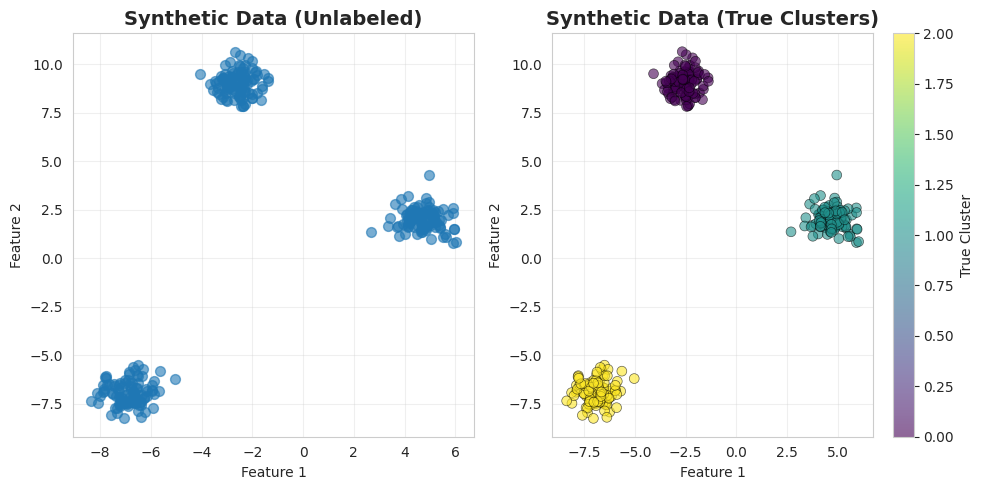

Dataset shape: (300, 2)
Number of true clusters: 3


In [ ]:
# Generate synthetic dataset with clear clusters
np.random.seed(42)

# Create 3 distinct clusters
X_synthetic, y_true = make_blobs(n_samples=300,
                                  centers=3,
                                  n_features=2,
                                  cluster_std=0.6,
                                  random_state=42)

# Visualize the synthetic data
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_synthetic[:, 0], X_synthetic[:, 1], alpha=0.6, s=50)
plt.title('Synthetic Data (Unlabeled)', fontsize=14, fontweight='bold')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(X_synthetic[:, 0], X_synthetic[:, 1], c=y_true,
            cmap='viridis', alpha=0.6, s=50, edgecolors='k', linewidth=0.5)
plt.title('Synthetic Data (True Clusters)', fontsize=14, fontweight='bold')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='True Cluster')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Dataset shape: {X_synthetic.shape}")
print(f"Number of true clusters: {len(np.unique(y_true))}")


---
## 2. Hierarchical Clustering

Hierarchical clustering builds a tree-like structure (dendrogram) of nested clusters. There are two main approaches:

### 2.1 Agglomerative (Bottom-Up)
- Starts with each data point as its own cluster
- Iteratively merges the closest pairs of clusters
- Continues until all points are in a single cluster

### 2.2 Divisive (Top-Down)
- Starts with all data points in one cluster
- Iteratively splits clusters into smaller ones
- Continues until each point is its own cluster

### Linkage Methods:
- **Single Linkage**: Minimum distance between clusters
- **Complete Linkage**: Maximum distance between clusters  
- **Average Linkage**: Average distance between all pairs
- **Ward's Method**: Minimizes within-cluster variance (most commonly used)

### Advantages:
- No need to specify number of clusters beforehand
- Produces a dendrogram for visualization
- Can capture hierarchical relationships

### Disadvantages:
- Computationally expensive for large datasets: $O(n^3)$ time complexity
- Sensitive to noise and outliers
- Cannot undo previous merge/split decisions


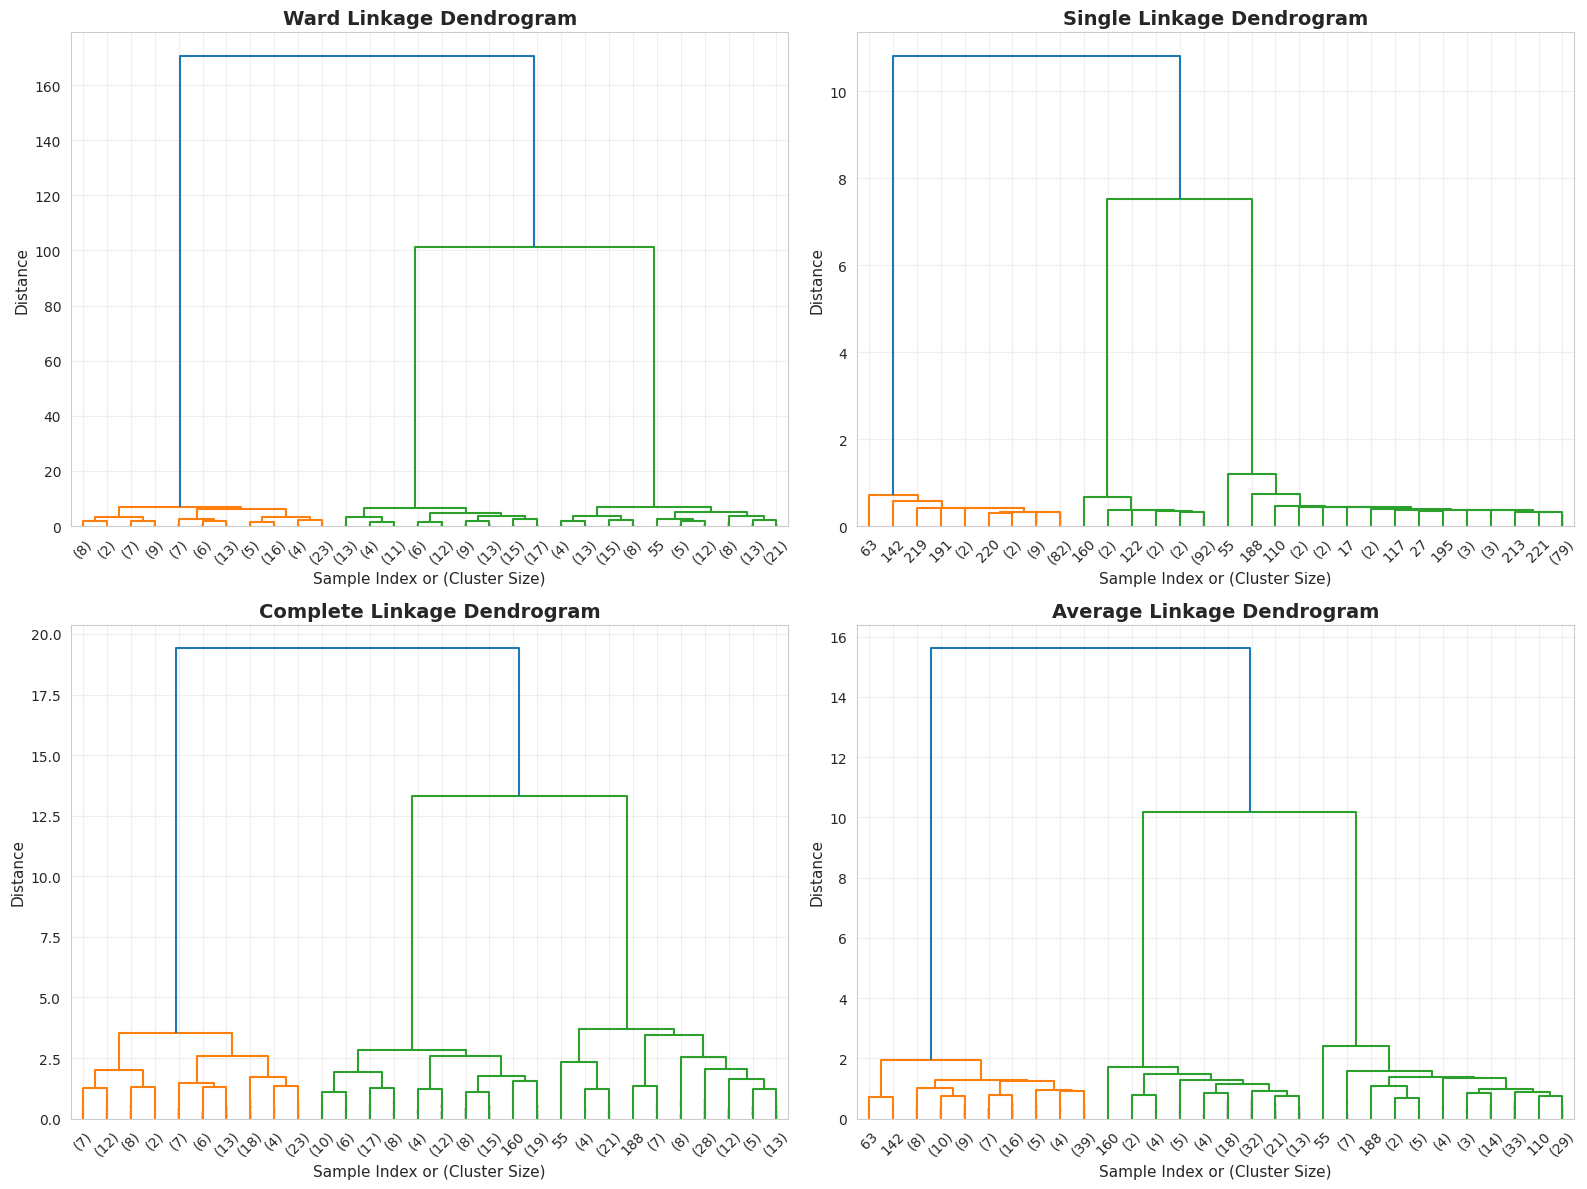

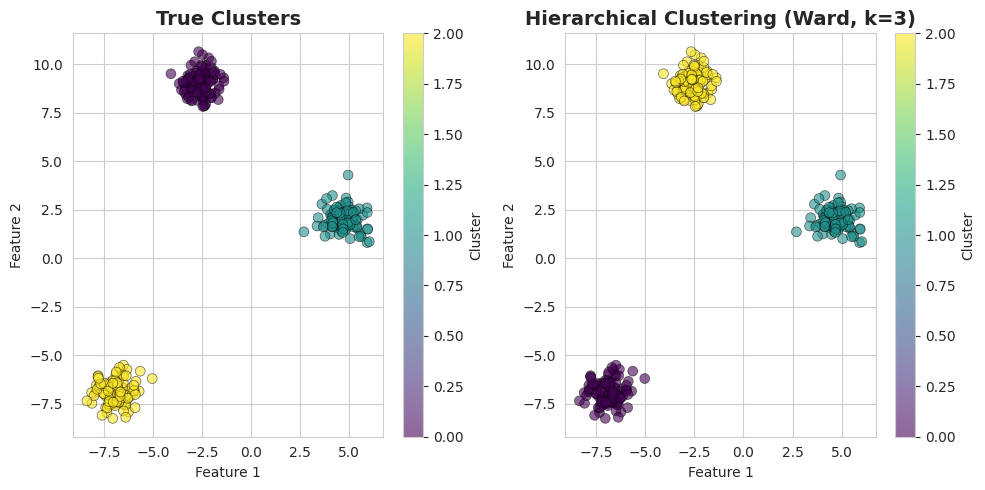

Cluster distribution: [100 100 100]


In [ ]:
# Perform hierarchical clustering with different linkage methods
linkage_methods = ['ward', 'single', 'complete', 'average']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, method in enumerate(linkage_methods):
    # Compute linkage matrix
    Z = linkage(X_synthetic, method=method)

    # Create dendrogram
    axes[idx].set_title(f'{method.capitalize()} Linkage Dendrogram',
                        fontsize=14, fontweight='bold')
    dendrogram(Z, ax=axes[idx], truncate_mode='lastp', p=30,
               leaf_font_size=10, show_contracted=True)
    axes[idx].set_xlabel('Sample Index or (Cluster Size)', fontsize=11)
    axes[idx].set_ylabel('Distance', fontsize=11)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Apply agglomerative clustering with Ward's method
n_clusters = 3
hierarchical = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
y_hierarchical = hierarchical.fit_predict(X_synthetic)

# Visualize hierarchical clustering results
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_synthetic[:, 0], X_synthetic[:, 1], c=y_true,
            cmap='viridis', alpha=0.6, s=50, edgecolors='k', linewidth=0.5)
plt.title('True Clusters', fontsize=14, fontweight='bold')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster')

plt.subplot(1, 2, 2)
plt.scatter(X_synthetic[:, 0], X_synthetic[:, 1], c=y_hierarchical,
            cmap='viridis', alpha=0.6, s=50, edgecolors='k', linewidth=0.5)
plt.title(f'Hierarchical Clustering (Ward, k={n_clusters})',
          fontsize=14, fontweight='bold')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster')

plt.tight_layout()
plt.show()

print(f"Cluster distribution: {np.bincount(y_hierarchical)}")


### 🔍 TO DO #1: Explore Hierarchical Clustering Linkage Methods

**Task:** Experiment with different linkage methods and analyze how they affect cluster formation.

**Try modifying:**
- Change `method` parameter in the linkage function: 'ward', 'single', 'complete', 'average'
- Adjust `n_clusters` from 2 to 5
- Generate new synthetic data with different `cluster_std` values (try 0.3, 1.0, 1.5)

**Questions to consider:**
1. How do different linkage methods affect the dendrogram structure?
2. Which linkage method produces the most balanced clusters?
3. How does increasing cluster overlap (higher `cluster_std`) impact clustering quality?
4. At what height should you cut the dendrogram to get optimal clusters?

**Expected insight:** Understanding that Ward's method typically produces more balanced clusters and is less sensitive to outliers compared to single linkage, which can create chain effects.


---
## 3. K-Means Clustering

K-means is an iterative partitioning algorithm that divides data into K distinct, non-overlapping clusters. It's one of the most widely used clustering algorithms due to its simplicity and efficiency.

### Algorithm Steps:

1. **Initialization**: Randomly select K data points as initial centroids
2. **Assignment**: Assign each data point to the nearest centroid (using Euclidean distance)
3. **Update**: Recalculate centroids as the mean of all points in each cluster
4. **Repeat**: Iterate steps 2-3 until convergence (centroids no longer move significantly)

### Mathematical Formulation:

The objective is to minimize the **Within-Cluster Sum of Squares (WCSS)**:

$$WCSS = \sum_{i=1}^{K} \sum_{x \in C_i} ||x - \mu_i||^2$$

where:
- $K$ = number of clusters
- $C_i$ = cluster $i$
- $\mu_i$ = centroid of cluster $i$
- $x$ = data point

### Advantages:
- Fast and scalable: $O(nKt)$ where n=samples, K=clusters, t=iterations
- Easy to understand and implement
- Works well with spherical clusters of similar size
- Guaranteed to converge

### Disadvantages:
- Requires specifying K beforehand
- Sensitive to initial centroid placement
- Assumes spherical clusters of similar variance
- Sensitive to outliers
- Can get stuck in local optima


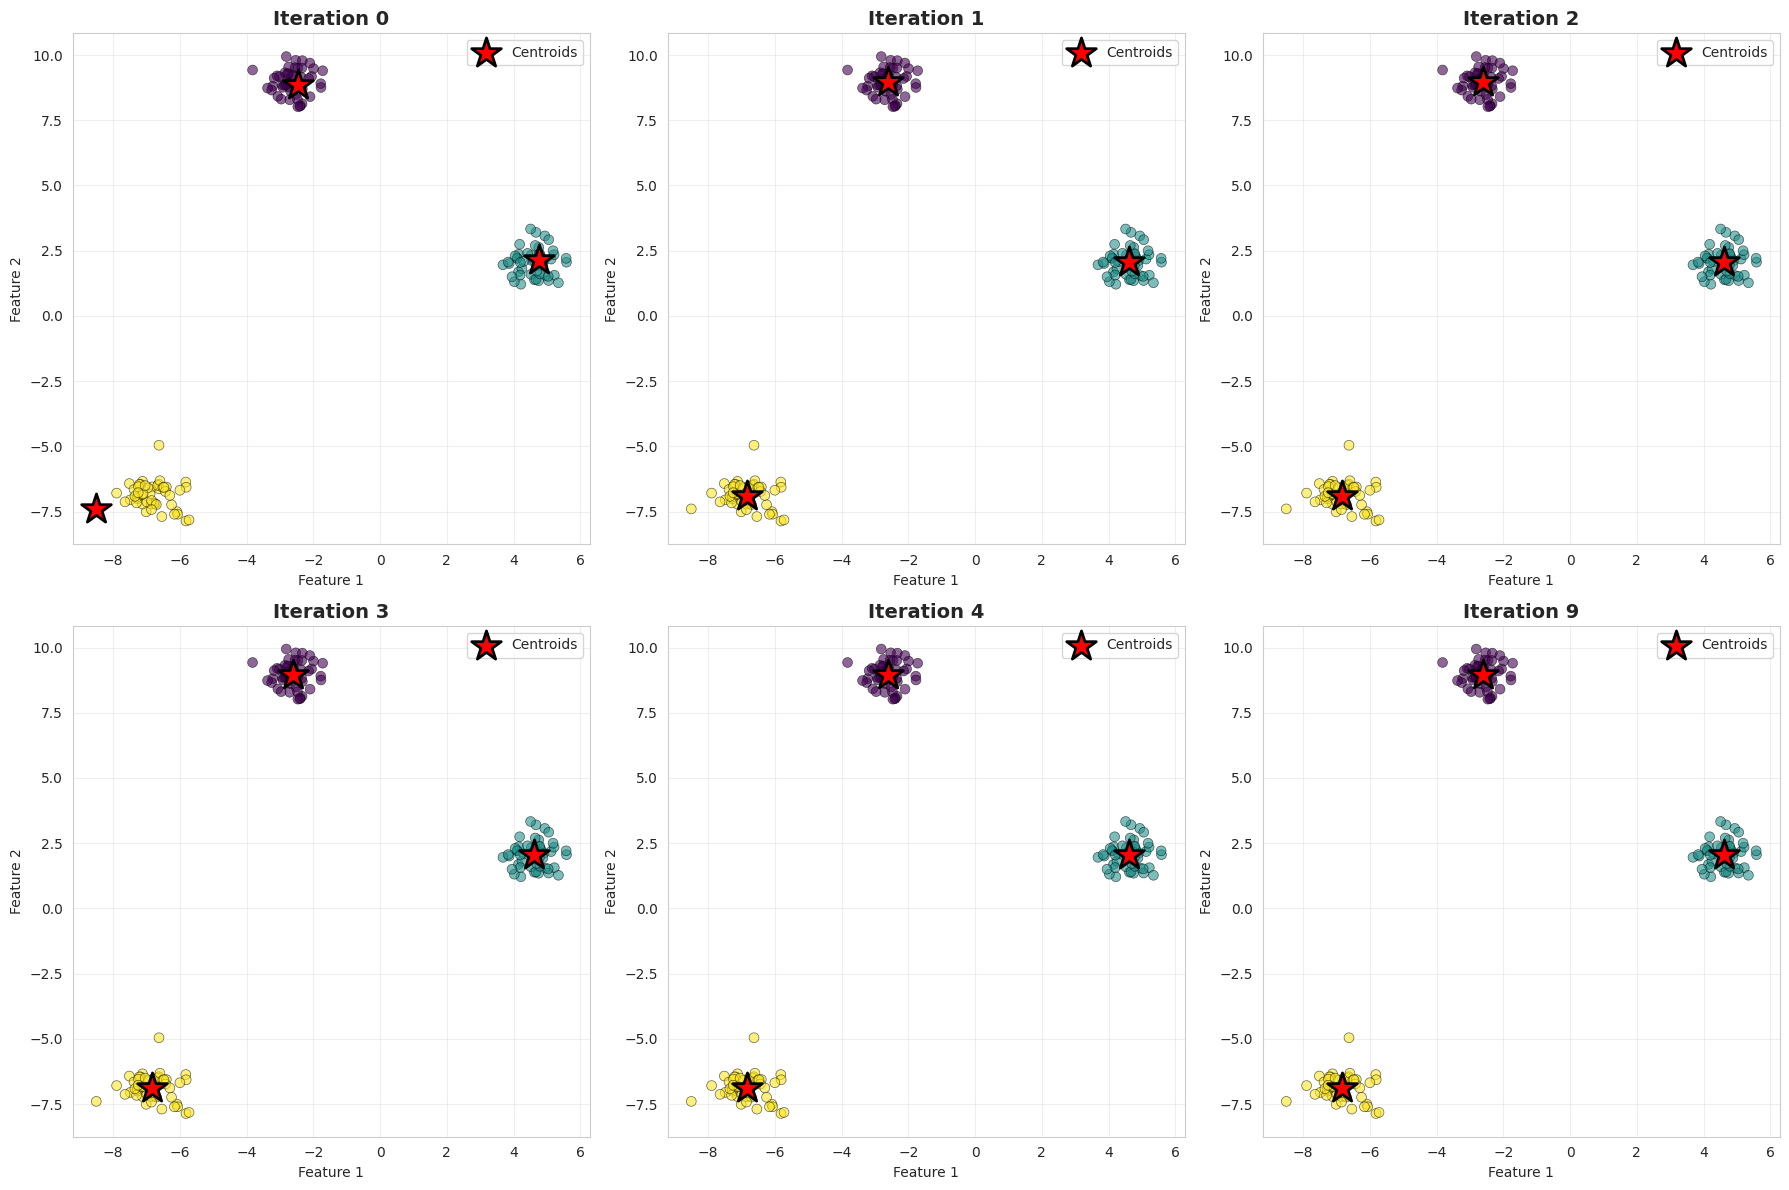


K-means converged in 2 iterations
Final WCSS (inertia): 204.07
Cluster centers:
[[-2.58361866  9.03185632]
 [-6.88217395 -6.94243433]
 [ 4.70421356  1.99562444]]

Cluster sizes: [100 100 100]


In [ ]:
# Visualize K-means algorithm steps
np.random.seed(42)

# Generate data for visualization
X_demo, _ = make_blobs(n_samples=150, centers=3, n_features=2,
                       cluster_std=0.5, random_state=42)

def plot_kmeans_iteration(X, n_clusters, max_iter=10):
    '''
    Visualize K-means algorithm iterations
    '''
    # Initialize with random centroids
    np.random.seed(42)
    initial_idx = np.random.choice(len(X), n_clusters, replace=False)
    centroids = X[initial_idx].copy()

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.ravel()

    iterations_to_show = [0, 1, 2, 3, 4, max_iter-1]

    for plot_idx, iteration in enumerate(iterations_to_show):
        if plot_idx >= len(axes):
            break

        ax = axes[plot_idx]

        # Perform iterations up to current step
        current_centroids = X[initial_idx].copy()
        for i in range(iteration + 1):
            # Assignment step
            distances = cdist(X, current_centroids, metric='euclidean')
            labels = np.argmin(distances, axis=1)

            # Update step
            if i < iteration:
                for k in range(n_clusters):
                    if np.sum(labels == k) > 0:
                        current_centroids[k] = X[labels == k].mean(axis=0)

        # Plot current state
        scatter = ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis',
                           alpha=0.6, s=50, edgecolors='k', linewidth=0.5)
        ax.scatter(current_centroids[:, 0], current_centroids[:, 1],
                  c='red', marker='*', s=500, edgecolors='black',
                  linewidth=2, label='Centroids', zorder=5)

        ax.set_title(f'Iteration {iteration}', fontsize=14, fontweight='bold')
        ax.set_xlabel('Feature 1')
        ax.set_ylabel('Feature 2')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_kmeans_iteration(X_demo, n_clusters=3, max_iter=10)

# Apply K-means clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_synthetic)

print(f"\nK-means converged in {kmeans.n_iter_} iterations")
print(f"Final WCSS (inertia): {kmeans.inertia_:.2f}")
print(f"Cluster centers:\n{kmeans.cluster_centers_}")
print(f"\nCluster sizes: {np.bincount(y_kmeans)}")


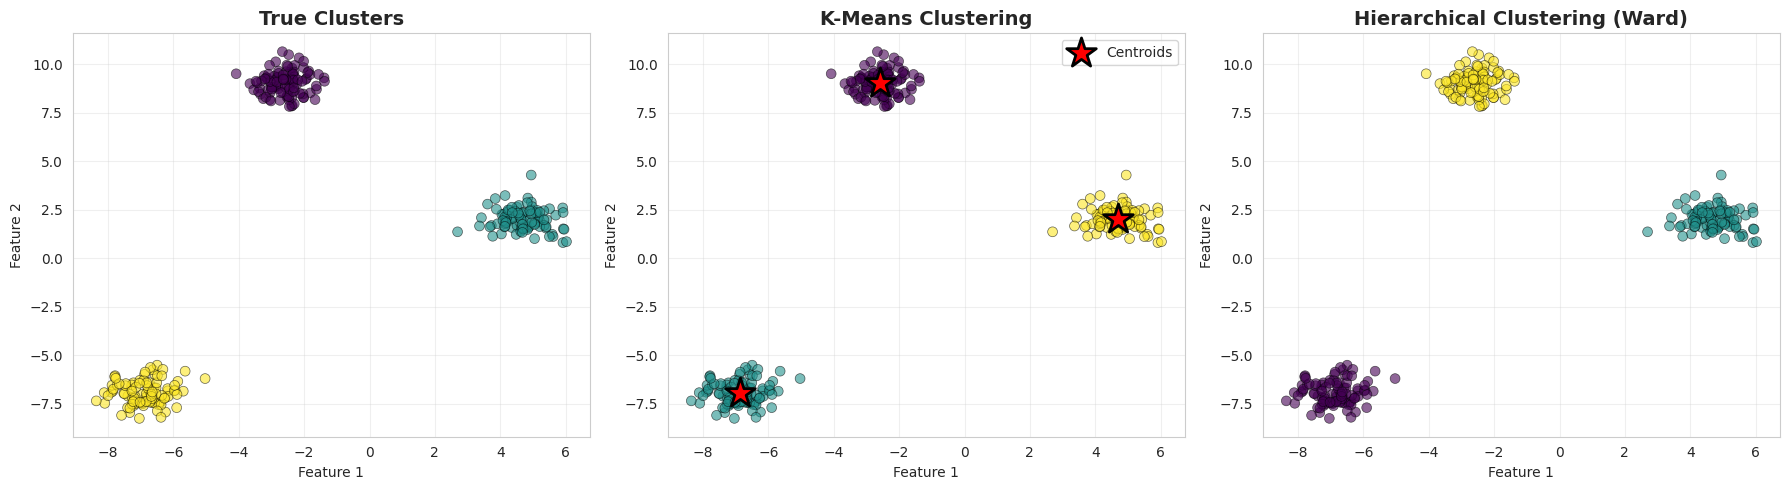


Clustering Comparison:
K-means vs True labels - ARI: 1.000
Hierarchical vs True labels - ARI: 1.000
K-means vs Hierarchical - ARI: 1.000

Note: ARI ranges from -1 to 1, where 1 indicates perfect agreement


In [ ]:
# Compare K-means with Hierarchical Clustering
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original data
axes[0].scatter(X_synthetic[:, 0], X_synthetic[:, 1], c=y_true,
               cmap='viridis', alpha=0.6, s=50, edgecolors='k', linewidth=0.5)
axes[0].set_title('True Clusters', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].grid(True, alpha=0.3)

# K-means
axes[1].scatter(X_synthetic[:, 0], X_synthetic[:, 1], c=y_kmeans,
               cmap='viridis', alpha=0.6, s=50, edgecolors='k', linewidth=0.5)
axes[1].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
               c='red', marker='*', s=500, edgecolors='black',
               linewidth=2, label='Centroids', zorder=5)
axes[1].set_title('K-Means Clustering', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Hierarchical
axes[2].scatter(X_synthetic[:, 0], X_synthetic[:, 1], c=y_hierarchical,
               cmap='viridis', alpha=0.6, s=50, edgecolors='k', linewidth=0.5)
axes[2].set_title('Hierarchical Clustering (Ward)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Feature 1')
axes[2].set_ylabel('Feature 2')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate agreement between methods
from sklearn.metrics import adjusted_rand_score

print("\nClustering Comparison:")
print(f"K-means vs True labels - ARI: {adjusted_rand_score(y_true, y_kmeans):.3f}")
print(f"Hierarchical vs True labels - ARI: {adjusted_rand_score(y_true, y_hierarchical):.3f}")
print(f"K-means vs Hierarchical - ARI: {adjusted_rand_score(y_kmeans, y_hierarchical):.3f}")
print("\nNote: ARI ranges from -1 to 1, where 1 indicates perfect agreement")


### 🔍 TO DO #2: Sensitivity to Initialization

**Task:** Investigate how K-means performance varies with different initializations.

**Try modifying:**
- Run K-means multiple times with different `random_state` values (try 0, 10, 42, 100, 999)
- Change `n_init` parameter (try 1, 5, 10, 50) - this controls how many times the algorithm runs with different initializations
- Observe the variation in final WCSS (`kmeans.inertia_`) and number of iterations

**Questions to consider:**
1. How much does the final WCSS vary across different random initializations?
2. Does increasing `n_init` lead to more stable results?
3. What happens when you set `n_init=1` vs `n_init=50`?
4. Can you find an initialization that leads to a local optimum (suboptimal clustering)?

**Expected insight:** K-means can converge to different local optima depending on initialization. Using multiple initializations (higher `n_init`) and selecting the best result helps find better global solutions.


---
## 4. Determining Optimal Number of Clusters

One of the key challenges in clustering is determining the optimal number of clusters (K). We'll explore two popular methods:

### 4.1 Elbow Method

The Elbow method plots **WCSS** against the number of clusters. The optimal K is where the curve bends sharply (forming an "elbow").

**Rationale:**
- As K increases, WCSS always decreases (more clusters = lower within-cluster variance)
- At some point, adding more clusters provides diminishing returns
- The "elbow point" represents the best trade-off between cluster compactness and simplicity

**Limitations:**
- The elbow may not always be clearly defined
- Subjective interpretation of where the elbow occurs
- May not work well with overlapping clusters


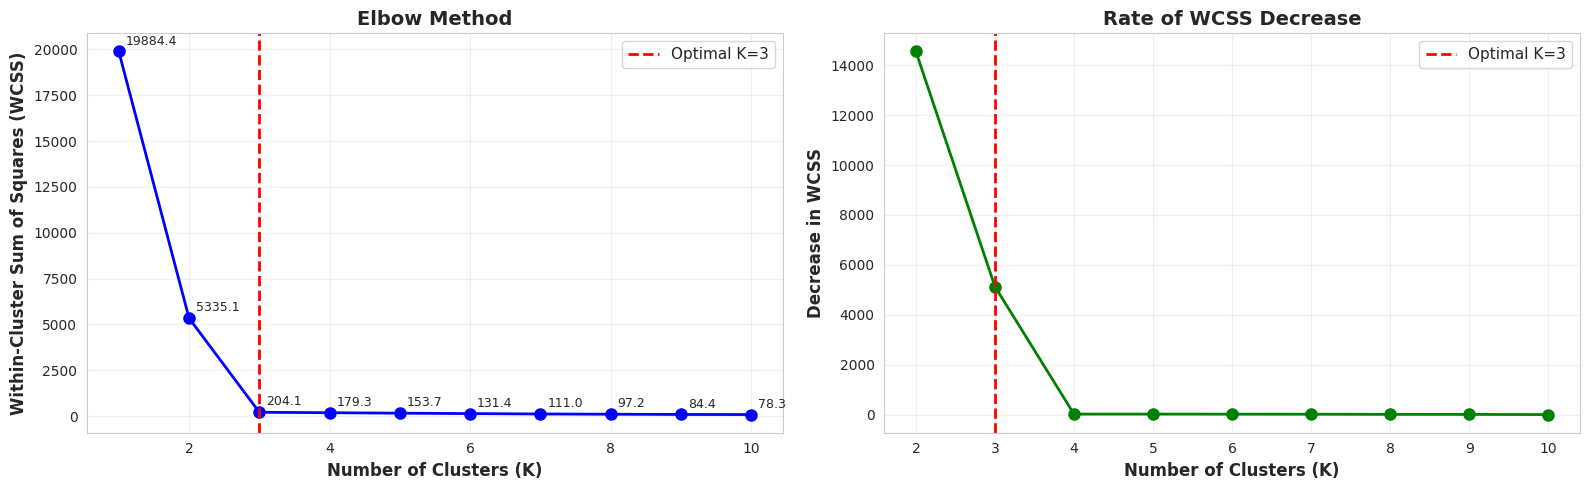


WCSS values for different K:
K=1: WCSS=19884.40
K=2: WCSS=5335.12
K=3: WCSS=204.07
K=4: WCSS=179.33
K=5: WCSS=153.75
K=6: WCSS=131.40
K=7: WCSS=110.98
K=8: WCSS=97.23
K=9: WCSS=84.37
K=10: WCSS=78.34


In [ ]:
# Implement Elbow Method
wcss = []
K_range = range(1, 11)
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_synthetic)
    wcss.append(kmeans.inertia_)

    # Silhouette score (undefined for k=1)
    if k > 1:
        score = silhouette_score(X_synthetic, kmeans.labels_)
        silhouette_scores.append(score)
    else:
        silhouette_scores.append(np.nan)

# Plot Elbow Curve
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Elbow plot
axes[0].plot(K_range, wcss, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12, fontweight='bold')
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=3, color='r', linestyle='--', linewidth=2, label='Optimal K=3')
axes[0].legend(fontsize=11)

# Add annotations
for i, k in enumerate(K_range):
    axes[0].annotate(f'{wcss[i]:.1f}',
                    xy=(k, wcss[i]),
                    xytext=(5, 5),
                    textcoords='offset points',
                    fontsize=9)

# Calculate rate of decrease
rate_of_decrease = np.diff(wcss)
axes[1].plot(K_range[1:], -rate_of_decrease, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Decrease in WCSS', fontsize=12, fontweight='bold')
axes[1].set_title('Rate of WCSS Decrease', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=3, color='r', linestyle='--', linewidth=2, label='Optimal K=3')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

print("\nWCSS values for different K:")
for k, w in zip(K_range, wcss):
    print(f"K={k}: WCSS={w:.2f}")


---
## 4.2 Silhouette Analysis

The **Silhouette Coefficient** measures how similar a data point is to its own cluster compared to other clusters.

### Silhouette Score Formula:

For each data point $i$:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

where:
- $a(i)$ = average distance from point $i$ to other points in the same cluster (intra-cluster distance)
- $b(i)$ = minimum average distance from point $i$ to points in other clusters (inter-cluster distance)

### Interpretation:
- $s(i)$ close to **+1**: Point is well-matched to its cluster
- $s(i)$ close to **0**: Point is on the border between clusters  
- $s(i)$ close to **-1**: Point may be assigned to the wrong cluster

### Average Silhouette Score:
- Range: [-1, 1]
- Higher values indicate better-defined clusters
- Optimal K has the highest average silhouette score

### Advantages over Elbow Method:
- Provides a quantitative measure of cluster quality
- Considers both cohesion and separation
- Less subjective than visual interpretation


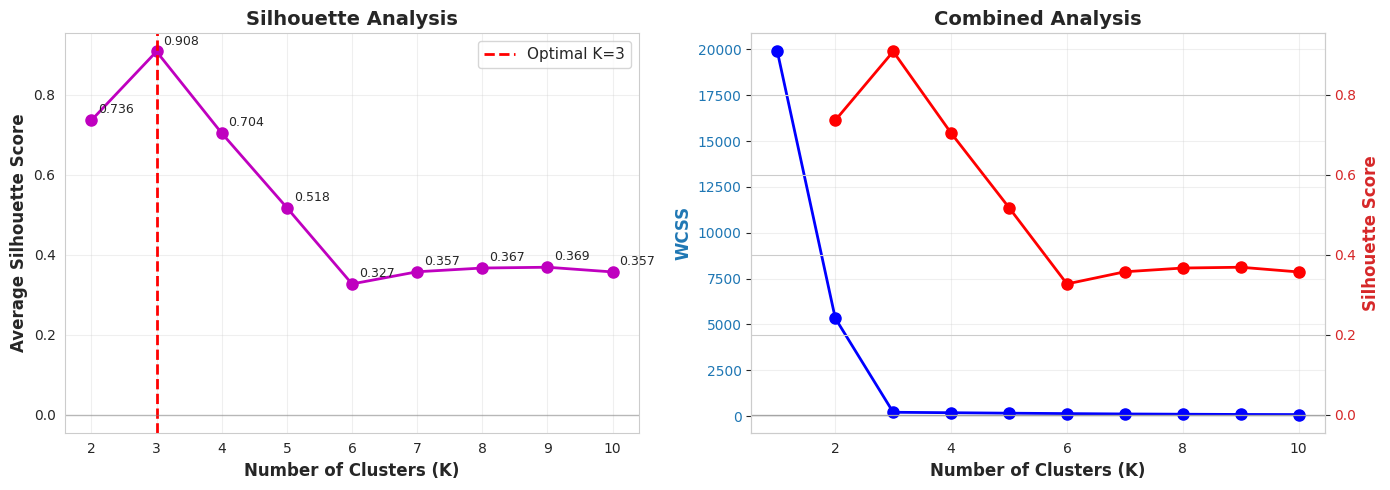


Silhouette Scores for different K:
K=2: Silhouette Score=0.7361
K=3: Silhouette Score=0.9084
K=4: Silhouette Score=0.7042
K=5: Silhouette Score=0.5177
K=6: Silhouette Score=0.3268
K=7: Silhouette Score=0.3573
K=8: Silhouette Score=0.3666
K=9: Silhouette Score=0.3686
K=10: Silhouette Score=0.3568

Optimal K based on Silhouette Score: 3


In [ ]:
# Plot Silhouette Scores
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(K_range[1:], silhouette_scores[1:], 'mo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12, fontweight='bold')
plt.ylabel('Average Silhouette Score', fontsize=12, fontweight='bold')
plt.title('Silhouette Analysis', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axvline(x=3, color='r', linestyle='--', linewidth=2, label='Optimal K=3')
plt.axhline(y=0, color='gray', linestyle='-', linewidth=1, alpha=0.5)
plt.legend(fontsize=11)

# Add annotations
for i, k in enumerate(K_range[1:], 1):
    if not np.isnan(silhouette_scores[i]):
        plt.annotate(f'{silhouette_scores[i]:.3f}',
                    xy=(k, silhouette_scores[i]),
                    xytext=(5, 5),
                    textcoords='offset points',
                    fontsize=9)

# Combined view
plt.subplot(1, 2, 2)
ax1 = plt.gca()
color1 = 'tab:blue'
ax1.set_xlabel('Number of Clusters (K)', fontsize=12, fontweight='bold')
ax1.set_ylabel('WCSS', color=color1, fontsize=12, fontweight='bold')
ax1.plot(K_range, wcss, 'bo-', linewidth=2, markersize=8, label='WCSS')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color2, fontsize=12, fontweight='bold')
ax2.plot(K_range[1:], silhouette_scores[1:], 'ro-', linewidth=2, markersize=8, label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.axhline(y=0, color='gray', linestyle='-', linewidth=1, alpha=0.5)

plt.title('Combined Analysis', fontsize=14, fontweight='bold')
fig = plt.gcf()
fig.tight_layout()
plt.show()

print("\nSilhouette Scores for different K:")
for k, score in zip(K_range[1:], silhouette_scores[1:]):
    print(f"K={k}: Silhouette Score={score:.4f}")

optimal_k = K_range[1:][np.argmax(silhouette_scores[1:])]
print(f"\nOptimal K based on Silhouette Score: {optimal_k}")


### 🔍 TO DO #3: Determine Optimal K for New Dataset

**Task:** Apply both Elbow and Silhouette methods to determine the optimal number of clusters for a new dataset.

**Try modifying:**
- Generate new synthetic data with different number of clusters: `make_blobs(centers=4, cluster_std=0.8)`
- Try different `cluster_std` values to control cluster overlap (0.3, 0.8, 1.5)
- Change number of samples to see how dataset size affects results

**Questions to consider:**
1. Do the Elbow method and Silhouette analysis agree on the optimal K?
2. How does cluster overlap affect the clarity of the elbow point?
3. What happens to silhouette scores when clusters overlap significantly?
4. At what point does increasing K not improve clustering quality?

**Expected insight:** Both methods may not always agree, especially with overlapping clusters. The Elbow method can be ambiguous, while Silhouette analysis provides a more quantitative assessment. Real-world data often has no clear "correct" number of clusters.


---
## 5. Real-World Application: Iris Dataset

The Iris dataset is a classic dataset in machine learning containing measurements of 150 iris flowers from three species. We'll apply clustering to discover species groupings based only on flower measurements (unsupervised).

**Features:**
- Sepal Length (cm)
- Sepal Width (cm)
- Petal Length (cm)
- Petal Width (cm)

**True Species:** Setosa, Versicolor, Virginica


Iris Dataset Overview:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4               3.9                1.7               0.4   
6                4.6               3.4                1.4               0.3   
7                5.0               3.4                1.5               0.2   
8                4.4               2.9                1.4               0.2   
9                4.9               3.1                1.5               0.1   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  
5  setosa  
6  setosa  
7  setosa  

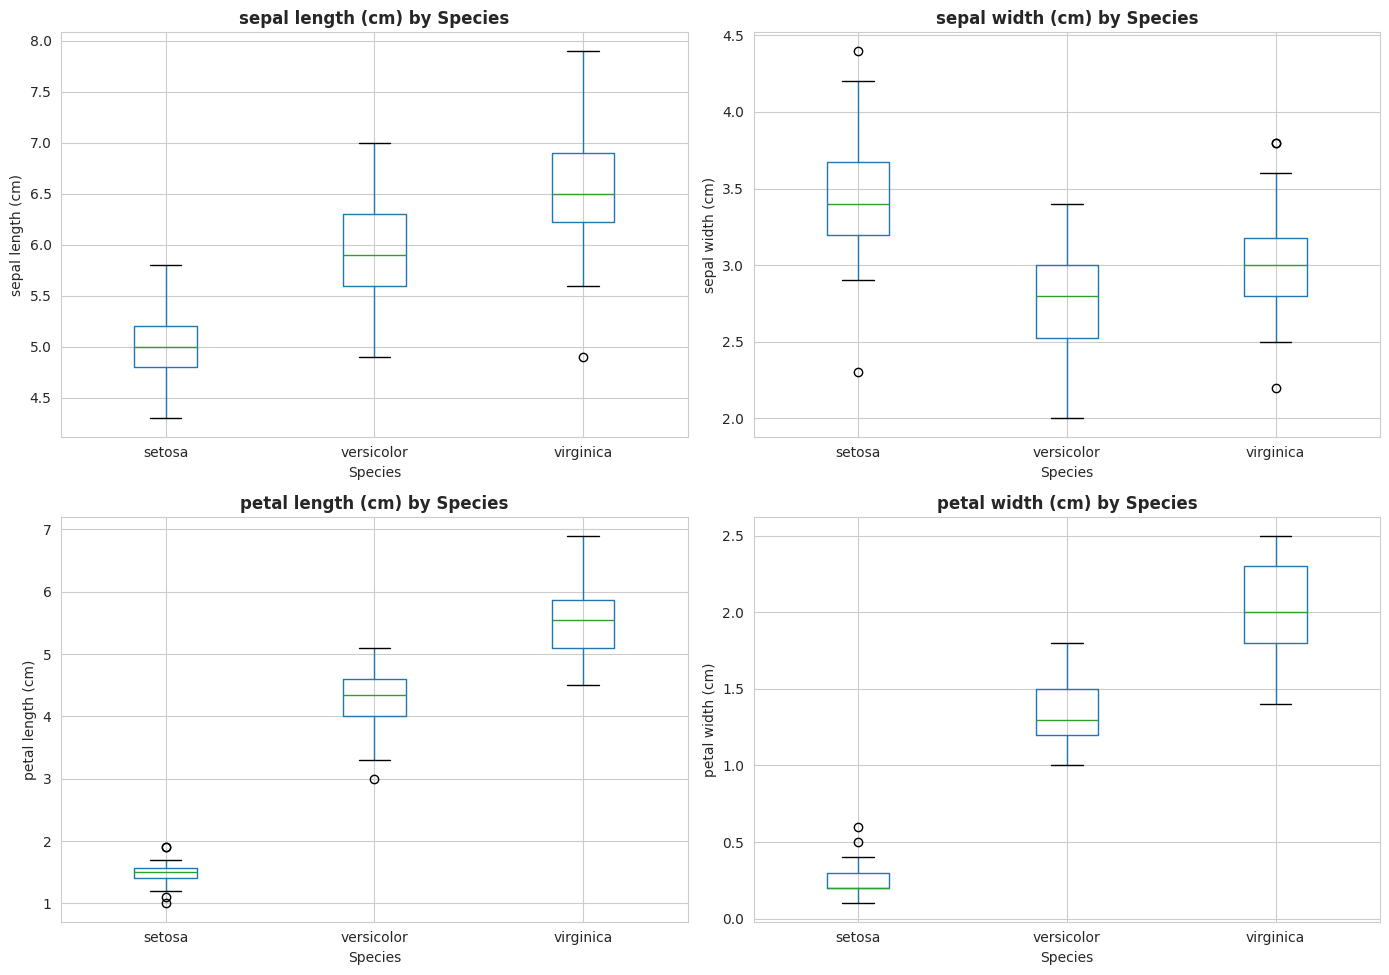

In [ ]:
# Load Iris dataset
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Create DataFrame for easy manipulation
df_iris = pd.DataFrame(X_iris, columns=feature_names)
df_iris['species'] = [target_names[i] for i in y_iris]

print("Iris Dataset Overview:")
print(df_iris.head(10))
print(f"\nDataset shape: {df_iris.shape}")
print(f"\nSpecies distribution:")
print(df_iris['species'].value_counts())

# Summary statistics
print("\nSummary Statistics:")
print(df_iris.describe())

# Correlation analysis
print("\nFeature Correlations:")
correlation_matrix = df_iris.iloc[:, :-1].corr()
print(correlation_matrix)

# Visualize feature distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, feature in enumerate(feature_names):
    df_iris.boxplot(column=feature, by='species', ax=axes[idx])
    axes[idx].set_title(f'{feature} by Species', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Species')
    axes[idx].set_ylabel(feature)

plt.suptitle('')
plt.tight_layout()
plt.show()


Explained variance ratio: [0.72962445 0.22850762]
Total variance explained: 95.81%


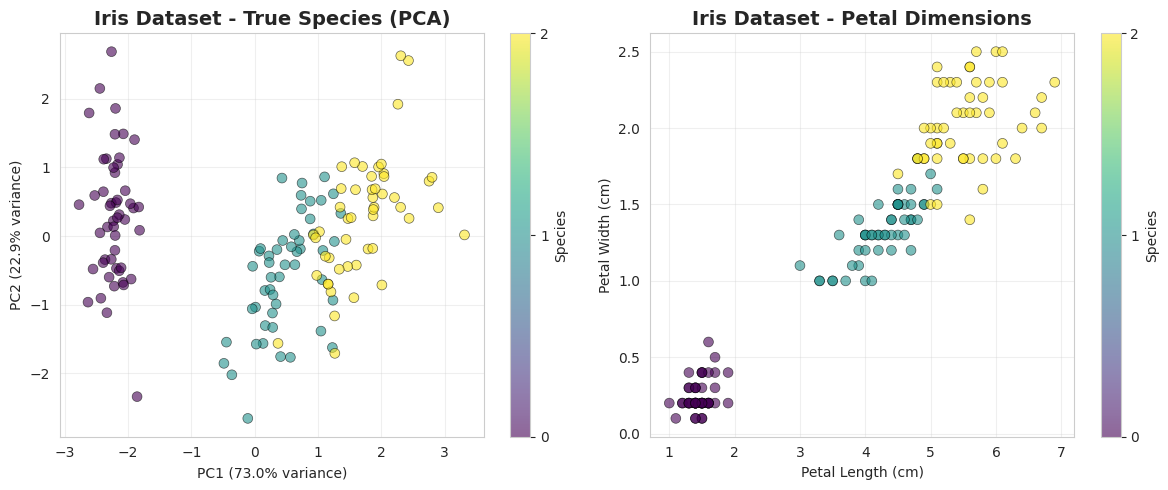

In [ ]:
# Standardize features (important for K-means)
scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)

# Apply PCA for 2D visualization
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_iris_pca = pca.fit_transform(X_iris_scaled)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.2%}")

# Visualize in PCA space
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
scatter = plt.scatter(X_iris_pca[:, 0], X_iris_pca[:, 1], c=y_iris,
                     cmap='viridis', alpha=0.6, s=50, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, ticks=[0, 1, 2], label='Species')
plt.title('Iris Dataset - True Species (PCA)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.grid(True, alpha=0.3)

# Also show petal length vs petal width (most discriminative features)
plt.subplot(1, 2, 2)
scatter = plt.scatter(X_iris[:, 2], X_iris[:, 3], c=y_iris,
                     cmap='viridis', alpha=0.6, s=50, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, ticks=[0, 1, 2], label='Species')
plt.title('Iris Dataset - Petal Dimensions', fontsize=14, fontweight='bold')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


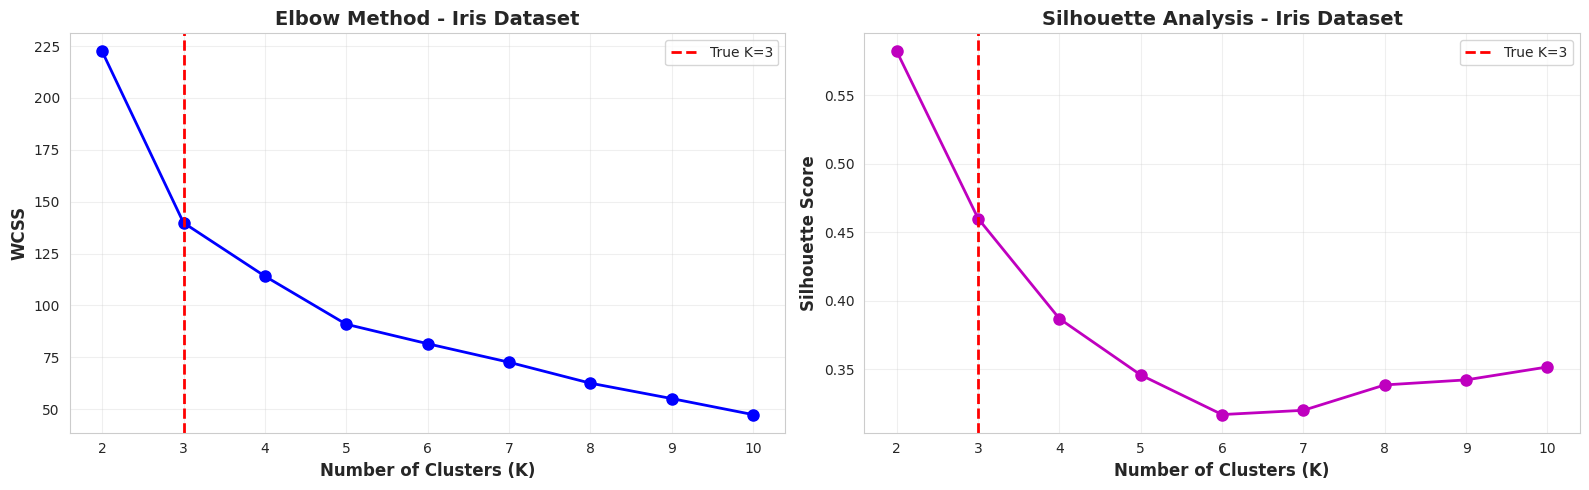


Optimal K based on Silhouette Score: 2
True number of species: 3

Silhouette scores:
K=2: 0.5818
K=3: 0.4599
K=4: 0.3869
K=5: 0.3459
K=6: 0.3171
K=7: 0.3202
K=8: 0.3387
K=9: 0.3424
K=10: 0.3518


In [ ]:
# Determine optimal K for Iris dataset
wcss_iris = []
silhouette_iris = []
K_range_iris = range(2, 11)

for k in K_range_iris:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_iris_scaled)
    wcss_iris.append(kmeans.inertia_)
    silhouette_iris.append(silhouette_score(X_iris_scaled, kmeans.labels_))

# Plot analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Elbow plot
axes[0].plot(K_range_iris, wcss_iris, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('WCSS', fontsize=12, fontweight='bold')
axes[0].set_title('Elbow Method - Iris Dataset', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=3, color='r', linestyle='--', linewidth=2, label='True K=3')
axes[0].legend()

# Silhouette plot
axes[1].plot(K_range_iris, silhouette_iris, 'mo-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Silhouette Score', fontsize=12, fontweight='bold')
axes[1].set_title('Silhouette Analysis - Iris Dataset', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=3, color='r', linestyle='--', linewidth=2, label='True K=3')
axes[1].legend()

plt.tight_layout()
plt.show()

optimal_k_iris = K_range_iris[np.argmax(silhouette_iris)]
print(f"\nOptimal K based on Silhouette Score: {optimal_k_iris}")
print(f"True number of species: 3")
print(f"\nSilhouette scores:")
for k, score in zip(K_range_iris, silhouette_iris):
    print(f"K={k}: {score:.4f}")


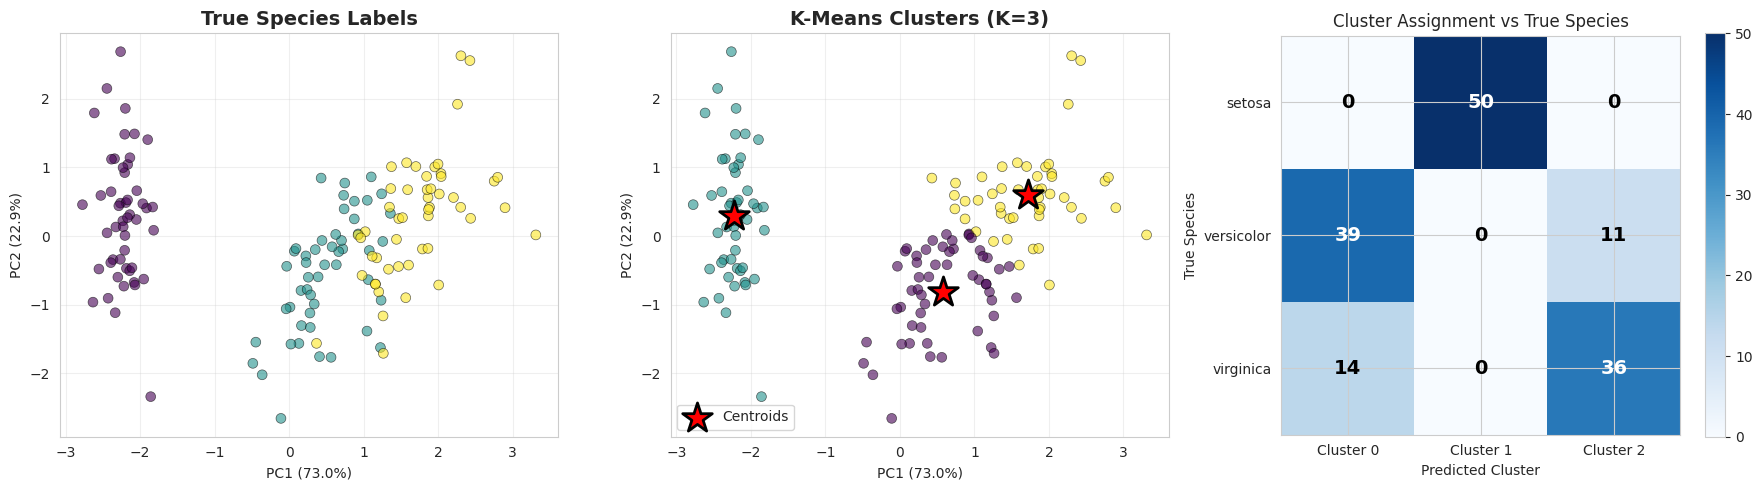


Clustering Performance:
Adjusted Rand Index: 0.6201
Silhouette Score: 0.4599

Cluster sizes: [53 50 47]

Observation: Notice how Versicolor and Virginica overlap,
making them harder to separate than Setosa.


In [ ]:
# Apply K-means with optimal K
kmeans_iris = KMeans(n_clusters=3, random_state=42, n_init=10)
y_kmeans_iris = kmeans_iris.fit_predict(X_iris_scaled)

# Visualize clustering results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# True labels
axes[0].scatter(X_iris_pca[:, 0], X_iris_pca[:, 1], c=y_iris,
               cmap='viridis', alpha=0.6, s=50, edgecolors='k', linewidth=0.5)
axes[0].set_title('True Species Labels', fontsize=14, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0].grid(True, alpha=0.3)

# K-means clusters
axes[1].scatter(X_iris_pca[:, 0], X_iris_pca[:, 1], c=y_kmeans_iris,
               cmap='viridis', alpha=0.6, s=50, edgecolors='k', linewidth=0.5)
# Transform centroids to PCA space
centroids_pca = pca.transform(kmeans_iris.cluster_centers_)
axes[1].scatter(centroids_pca[:, 0], centroids_pca[:, 1],
               c='red', marker='*', s=500, edgecolors='black',
               linewidth=2, label='Centroids', zorder=5)
axes[1].set_title('K-Means Clusters (K=3)', fontsize=14, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Confusion matrix style comparison
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_iris, y_kmeans_iris)

im = axes[2].imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
axes[2].figure.colorbar(im, ax=axes[2])
axes[2].set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=['Cluster 0', 'Cluster 1', 'Cluster 2'],
           yticklabels=target_names,
           title='Cluster Assignment vs True Species',
           ylabel='True Species',
           xlabel='Predicted Cluster')

# Add text annotations
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[2].text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black",
                    fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Calculate performance metrics
ari = adjusted_rand_score(y_iris, y_kmeans_iris)
sil_score = silhouette_score(X_iris_scaled, y_kmeans_iris)

print(f"\nClustering Performance:")
print(f"Adjusted Rand Index: {ari:.4f}")
print(f"Silhouette Score: {sil_score:.4f}")
print(f"\nCluster sizes: {np.bincount(y_kmeans_iris)}")
print(f"\nObservation: Notice how Versicolor and Virginica overlap,")
print(f"making them harder to separate than Setosa.")


### 🔍 TO DO #4: Feature Selection Impact on Clustering

**Task:** Investigate how different feature combinations affect clustering quality in the Iris dataset.

**Try modifying:**
- Use only petal measurements: `X_iris[:, 2:4]` (columns 2 and 3)
- Use only sepal measurements: `X_iris[:, 0:2]` (columns 0 and 1)
- Try single features: `X_iris[:, [2]]` (only petal length)
- Compare clustering quality using silhouette scores

**Questions to consider:**
1. Which features are most important for distinguishing species?
2. Can you achieve good clustering with just 2 features? Which 2?
3. How does removing the most discriminative features affect clustering?
4. What does this tell you about feature engineering in unsupervised learning?

**Expected insight:** Petal measurements (length and width) are more discriminative than sepal measurements for iris species. Feature selection significantly impacts clustering quality, and domain knowledge about which features matter is crucial for effective unsupervised learning.


---
## 6. Real-World Application: Wine Dataset

The Wine dataset contains chemical analysis results of wines from three different cultivars in Italy. This is a more challenging clustering problem with 13 features.

**Features (13 chemical properties):**
- Alcohol, Malic acid, Ash, Alkalinity of ash
- Magnesium, Total phenols, Flavanoids, Nonflavanoid phenols
- Proanthocyanins, Color intensity, Hue
- OD280/OD315 of diluted wines, Proline

**Goal:** Discover wine cultivar groups based on chemical composition.


Wine Dataset Overview:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  prolin

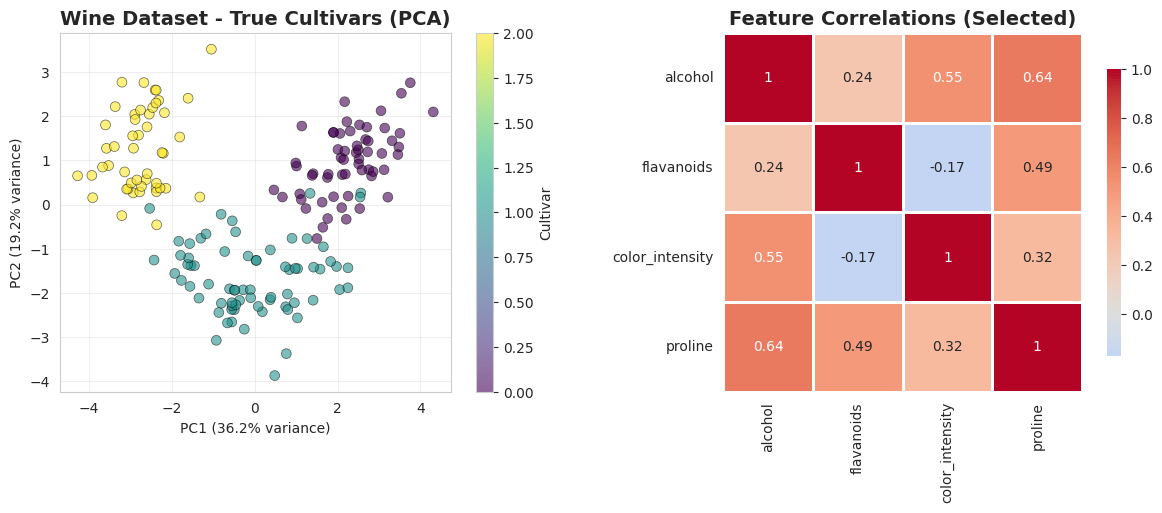

In [ ]:
# Load Wine dataset
wine = load_wine()
X_wine = wine.data
y_wine = wine.target
wine_features = wine.feature_names
wine_targets = wine.target_names

# Create DataFrame
df_wine = pd.DataFrame(X_wine, columns=wine_features)
df_wine['cultivar'] = [wine_targets[i] for i in y_wine]

print("Wine Dataset Overview:")
print(df_wine.head())
print(f"\nDataset shape: {df_wine.shape}")
print(f"\nCultivar distribution:")
print(df_wine['cultivar'].value_counts())

# Standardize features
scaler_wine = StandardScaler()
X_wine_scaled = scaler_wine.fit_transform(X_wine)

# Apply PCA for visualization
pca_wine = PCA(n_components=2)
X_wine_pca = pca_wine.fit_transform(X_wine_scaled)

print(f"\nPCA Explained variance: {pca_wine.explained_variance_ratio_}")
print(f"Total variance explained by PC1 & PC2: {sum(pca_wine.explained_variance_ratio_):.2%}")

# Visualize with PCA
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
scatter = plt.scatter(X_wine_pca[:, 0], X_wine_pca[:, 1], c=y_wine,
                     cmap='viridis', alpha=0.6, s=50, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Cultivar')
plt.title('Wine Dataset - True Cultivars (PCA)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca_wine.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca_wine.explained_variance_ratio_[1]:.1%} variance)')
plt.grid(True, alpha=0.3)

# Correlation heatmap of top features
plt.subplot(1, 2, 2)
top_features = ['alcohol', 'flavanoids', 'color_intensity', 'proline']
sns.heatmap(df_wine[top_features].corr(), annot=True, cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlations (Selected)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


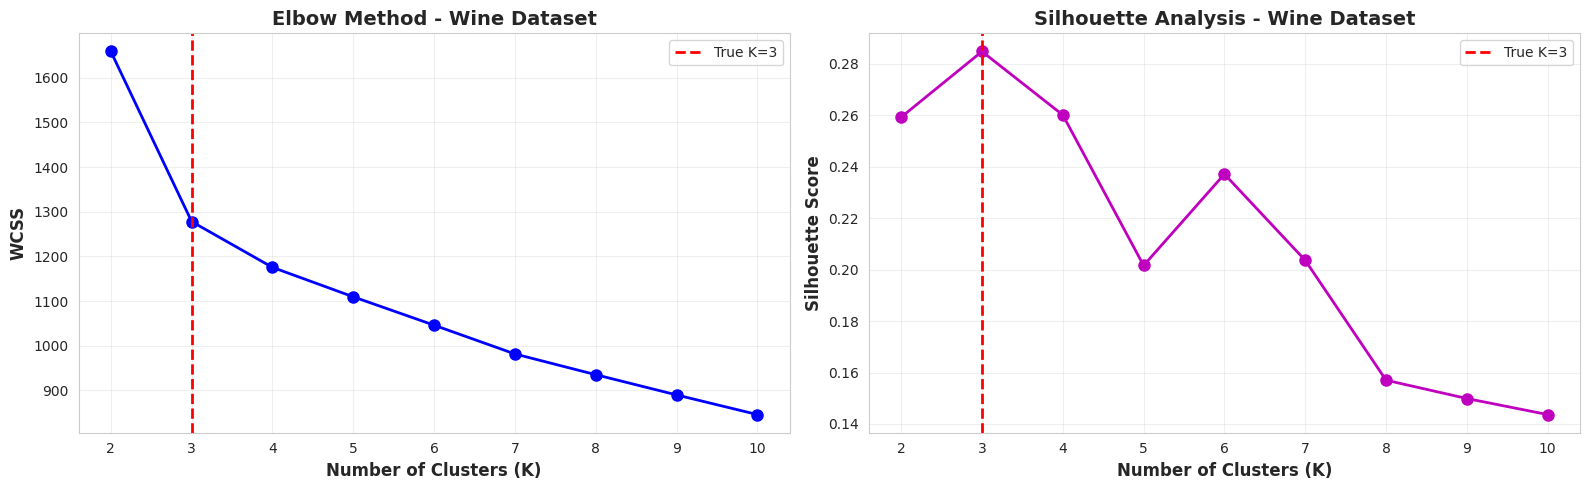


Optimal K based on Silhouette Score: 3
True number of cultivars: 3


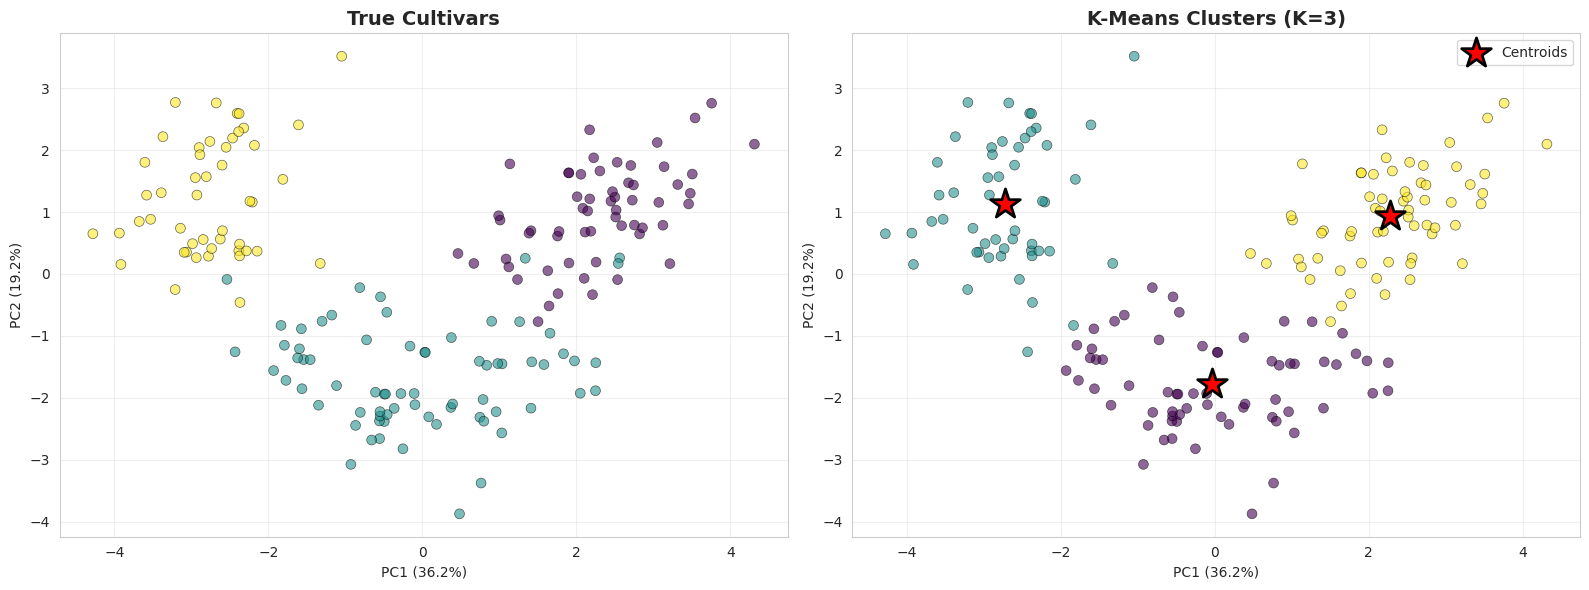


Clustering Performance:
Adjusted Rand Index: 0.8975
Silhouette Score: 0.2849
Cluster sizes: [65 51 62]


In [ ]:
# Determine optimal K for Wine dataset
wcss_wine = []
silhouette_wine = []
K_range_wine = range(2, 11)

for k in K_range_wine:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_wine_scaled)
    wcss_wine.append(kmeans.inertia_)
    silhouette_wine.append(silhouette_score(X_wine_scaled, kmeans.labels_))

# Plot analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(K_range_wine, wcss_wine, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('WCSS', fontsize=12, fontweight='bold')
axes[0].set_title('Elbow Method - Wine Dataset', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=3, color='r', linestyle='--', linewidth=2, label='True K=3')
axes[0].legend()

axes[1].plot(K_range_wine, silhouette_wine, 'mo-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Silhouette Score', fontsize=12, fontweight='bold')
axes[1].set_title('Silhouette Analysis - Wine Dataset', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=3, color='r', linestyle='--', linewidth=2, label='True K=3')
axes[1].legend()

plt.tight_layout()
plt.show()

optimal_k_wine = K_range_wine[np.argmax(silhouette_wine)]
print(f"\nOptimal K based on Silhouette Score: {optimal_k_wine}")
print(f"True number of cultivars: 3")

# Apply K-means with K=3
kmeans_wine = KMeans(n_clusters=3, random_state=42, n_init=10)
y_kmeans_wine = kmeans_wine.fit_predict(X_wine_scaled)

# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(X_wine_pca[:, 0], X_wine_pca[:, 1], c=y_wine,
               cmap='viridis', alpha=0.6, s=50, edgecolors='k', linewidth=0.5)
axes[0].set_title('True Cultivars', fontsize=14, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca_wine.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca_wine.explained_variance_ratio_[1]:.1%})')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(X_wine_pca[:, 0], X_wine_pca[:, 1], c=y_kmeans_wine,
               cmap='viridis', alpha=0.6, s=50, edgecolors='k', linewidth=0.5)
centroids_wine_pca = pca_wine.transform(kmeans_wine.cluster_centers_)
axes[1].scatter(centroids_wine_pca[:, 0], centroids_wine_pca[:, 1],
               c='red', marker='*', s=500, edgecolors='black',
               linewidth=2, label='Centroids', zorder=5)
axes[1].set_title('K-Means Clusters (K=3)', fontsize=14, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca_wine.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca_wine.explained_variance_ratio_[1]:.1%})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Performance metrics
ari_wine = adjusted_rand_score(y_wine, y_kmeans_wine)
sil_wine = silhouette_score(X_wine_scaled, y_kmeans_wine)

print(f"\nClustering Performance:")
print(f"Adjusted Rand Index: {ari_wine:.4f}")
print(f"Silhouette Score: {sil_wine:.4f}")
print(f"Cluster sizes: {np.bincount(y_kmeans_wine)}")


### 🔍 TO DO #5: Comprehensive Clustering Comparison

**Task:** Compare hierarchical clustering and K-means on the Wine dataset and analyze their differences.

**Try implementing:**
- Apply hierarchical clustering with Ward linkage to the scaled Wine data
- Compare the clustering results using Adjusted Rand Index
- Create visualizations showing both clustering methods side-by-side
- Experiment with different numbers of principal components (2, 3, 5) for dimensionality reduction

**Questions to consider:**
1. Which method produces more balanced cluster sizes?
2. How do the methods differ in their cluster assignments?
3. Does dimensionality reduction (PCA) improve or hurt clustering quality?
4. Which method is more sensitive to outliers in this dataset?
5. What are the computational time differences between the two methods?

**Expected insight:** Hierarchical clustering may produce different cluster assignments than K-means, especially for non-spherical clusters. K-means is generally faster but assumes spherical clusters, while hierarchical methods can capture more complex cluster shapes. The choice depends on data characteristics and computational constraints.


---
## 7. Summary and Best Practices

### Key Takeaways:

1. **Unsupervised Learning**: Clustering discovers natural groupings without labels
2. **Algorithm Selection**:
   - **K-means**: Fast, scalable, assumes spherical clusters
   - **Hierarchical**: No need to specify K, captures hierarchical structure, computationally expensive
3. **Determining K**: Use both Elbow and Silhouette methods for robust assessment
4. **Data Preprocessing**: Always standardize features before clustering
5. **Evaluation**: Use multiple metrics (WCSS, Silhouette, ARI) to assess quality

### Best Practices:

**Data Preparation:**
- Standardize/normalize features (especially for distance-based methods)
- Handle missing values appropriately
- Consider dimensionality reduction for high-dimensional data
- Remove or handle outliers carefully

**Model Selection:**
- Try multiple algorithms and compare results
- Use domain knowledge to validate cluster interpretability
- Consider computational constraints for large datasets

**Hyperparameter Tuning:**
- Always test multiple values of K
- For K-means, use multiple initializations (`n_init` parameter)
- For hierarchical, experiment with different linkage methods

**Validation:**
- Use multiple evaluation metrics
- Visualize results when possible (PCA for high-dimensional data)
- Validate clusters make sense in the problem domain
- Check cluster stability with different subsamples

**Common Pitfalls to Avoid:**
- Forgetting to standardize features
- Blindly trusting a single metric
- Not considering the interpretability of clusters
- Ignoring computational complexity for large datasets
- Forcing a specific number of clusters when data doesn't naturally cluster

### When to Use Clustering:

**Good Use Cases:**
- Customer segmentation for marketing
- Document organization and topic discovery
- Image segmentation
- Anomaly detection
- Gene expression analysis
- Recommendation systems (user grouping)

**Poor Use Cases:**
- When supervised labels are available (use classification instead)
- When clusters don't naturally exist in the data
- When interpretability of clusters is not important
- Very high-dimensional data without dimensionality reduction


---
## 8. Additional Resources and Further Reading

### Recommended Papers:
1. **MacQueen (1967)**: "Some Methods for Classification and Analysis of Multivariate Observations" - Original K-means paper
2. **Rousseeuw (1987)**: "Silhouettes: A Graphical Aid to the Interpretation and Validation of Cluster Analysis"
3. **Kaufman & Rousseeuw (1990)**: "Finding Groups in Data: An Introduction to Cluster Analysis"

### Online Resources:
- Scikit-learn Clustering Documentation: https://scikit-learn.org/stable/modules/clustering.html
- Visualizing K-means: https://www.naftaliharris.com/blog/visualizing-k-means-clustering/
- Hierarchical Clustering Explained: https://www.displayr.com/what-is-hierarchical-clustering/

### Advanced Topics to Explore:
- **DBSCAN**: Density-based clustering for arbitrary shapes
- **Gaussian Mixture Models**: Probabilistic clustering approach
- **Spectral Clustering**: Graph-based clustering
- **Mini-Batch K-means**: Scalable K-means for large datasets
- **Fuzzy C-means**: Soft clustering with probabilistic assignments
- **Consensus Clustering**: Combining multiple clustering results

### Python Libraries:
- **scikit-learn**: General-purpose machine learning
- **scipy**: Scientific computing and hierarchical clustering
- **hdbscan**: Density-based clustering
- **sklearn_extra**: Additional clustering algorithms

---

**Congratulations!** You've completed the Cluster Analysis module. You now have the foundation to apply clustering techniques to real-world problems and discover meaningful patterns in unlabeled data.
